# Per-window anomaly diagnostics — SMD Chronos-2 (instruction fine-tuned)

This notebook **decomposes the per-series metrics** (AUC-ROC ≈ 0.83 etc., from
`forward.py` / `run_forward_smd.sh`) **down to the individual 64-step forecast
windows**, so we can see *which windows* the model fails on and *how* (false
alarms on normal regions vs. missed anomalies).

**Why not just run `get_metrics()` per window?**
- AUC-ROC / AUC-PR are **undefined** on a window that is all-normal or all-anomaly
  (one class only). SMD anomaly segments are usually longer than 64 steps, so the
  vast majority of windows are single-class → AUC is NaN for them.
- VUS-PR/ROC use `slidingWindow=100`, longer than a 64-step window → meaningless.

**So per window we compute metrics that are defined everywhere:**
1. `fc_mse` — forecast error (mean squared error of the q50 forecast vs actual).
2. `anom_frac` — fraction of the 64 steps that are labelled anomalous.
3. `separation` — mean anomaly-score on anomalous steps minus mean on normal steps
   (how well the score ranks anomalies *inside* the window; needs both classes).
4. **Global-threshold confusion** — one threshold is chosen over the *entire* test
   set (the global best-F1 / oracle point), then TP/FP/FN/TN, precision, recall and
   F1 are counted *per window*. Defined for every window and comparable across them.
5. `AUC-ROC` / `AUC-PR` per window **where the window happens to be mixed** (reported,
   but expect few).

The per-window anomaly score is a **faithful slice of the exact series-level score**
that produced the reported metrics: we reproduce `forward.py`'s
score → robust-normalize → aggregate → smooth pipeline per series, then slice it at
the window boundaries. No change to inference; the model is run exactly as in
`forward.py`.


## 1. Configuration

Edit here. Defaults mirror `run_forward_smd.sh` (mse / l2) and point at the fine-tuned checkpoint that produced your screenshot. Set `CHECKPOINT = None` for the zero-shot base model.

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
from collections import defaultdict, OrderedDict
from tqdm.auto import tqdm
from scipy.ndimage import uniform_filter1d

import warnings
warnings.filterwarnings("ignore")

# --- paths ------------------------------------------------------------------
HERE      = os.path.abspath("")                      # .../SMD_run (run the nb from here)
WORK_ROOT = os.path.abspath(os.path.join(HERE, "..")) # .../rajib_work_space (chronos + VUS pkgs)
for p in (WORK_ROOT, HERE):
    if p not in sys.path:
        sys.path.insert(0, p)

TEST_PKL = os.path.join(HERE, "test_model_inputs.pkl")
META_PKL = os.path.join(HERE, "test_series_meta.pkl")
OUT_CSV  = os.path.join(HERE, "per_window_results.csv")

# --- model ------------------------------------------------------------------
MODEL_ID   = "amazon/chronos-2"
CHECKPOINT = os.path.join(HERE, "chronos2-single-stage_SMD", "finetuned-ckpt")  # None => zero-shot
DEVICE     = "cuda"

# --- sequence layout (must match data prep) ---------------------------------
N  = 256   # normal_signal_length
C  = 512   # context_length
P  = 64    # prediction_length
INPUT_PATCH_SIZE = 16
USE_NORMAL_PREFIX = CHECKPOINT is not None   # FT default: feed [normal|context]

# --- scoring (mirror run_forward_smd.sh: mse / l2) --------------------------
SCORE_METHOD = "mse"      # mse | interval | normalized_deviation | smape
AGG_METHOD   = "l2"       # l2 | max | mean | topk_mean
TOPK         = 4
SMOOTH_WINDOW = 5

# --- inference --------------------------------------------------------------
BATCH_WINDOWS      = 32
PREDICT_BATCH_SIZE = 160

fut_lo, fut_hi = N + C, N + C + P
in_lo = 0 if USE_NORMAL_PREFIX else N
model_context = fut_lo - in_lo
print(f"mode={'FINE-TUNED' if CHECKPOINT else 'ZERO-SHOT'} | "
      f"input target[:, {in_lo}:{fut_lo}] (len={model_context}) -> predict {P}; "
      f"score={SCORE_METHOD}/{AGG_METHOD} smooth={SMOOTH_WINDOW}")


mode=FINE-TUNED | input target[:, 0:768] (len=768) -> predict 64; score=mse/l2 smooth=5


/home/rajib/miniconda3/envs/debug_chronos/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Reuse `forward.py`'s scoring functions

Importing `forward` only pulls in the pure-numpy helpers (it does **not** load the model — that happens inside its `main()`), so the per-window score is computed with the *same* code path as the reported metrics.

In [2]:
from forward import compute_feature_score, robust_normalize_rows, aggregate_features
from VUS_ROC_VUS_PR.metrics import get_metrics          # series-level cross-check
from VUS_ROC_VUS_PR.basic_metrics import basic_metricor  # per-window AUC, no sklearn needed
_grader = basic_metricor()
print("helpers imported from forward.py + VUS package")


helpers imported from forward.py + VUS package


## 3. Load model (same logic as `forward.py`, incl. SEP restore for the LoRA checkpoint)

In [3]:
from chronos import BaseChronosPipeline
from chronos.chronos2 import Chronos2Pipeline
from transformers.utils.peft_utils import find_adapter_config_file

src = CHECKPOINT or MODEL_ID
if find_adapter_config_file(src) is not None:
    pipeline = Chronos2Pipeline.from_pretrained(src, device_map=DEVICE)
else:
    pipeline = BaseChronosPipeline.from_pretrained(src, device_map=DEVICE)

use_sep = bool(getattr(pipeline.model.chronos_config, "use_sep_token", False))
sep_idx = getattr(pipeline.model.chronos_config, "sep_patch_index", None)
if use_sep and USE_NORMAL_PREFIX:
    assert N % INPUT_PATCH_SIZE == 0, "N must be a multiple of INPUT_PATCH_SIZE"
    expected_sep = N // INPUT_PATCH_SIZE
    if sep_idx != expected_sep:
        pipeline.model.chronos_config.sep_patch_index = expected_sep
        sep_idx = expected_sep
    print(f"SEP boundary restored -> {sep_idx} patches = {sep_idx*INPUT_PATCH_SIZE} steps (== N={N})")

quantiles = list(pipeline.model.chronos_config.quantiles)
qi = {q: quantiles.index(q) for q in (0.1, 0.5, 0.9)}
print("loaded:", src, "| use_sep_token =", use_sep)


SEP boundary restored -> 16 patches = 256 steps (== N=256)
loaded: /home/rajib/Sir_git_TSAD/TSFM-anomaly/Chronos_Finetuning/rajib_work_space/SMD_run/chronos2-single-stage_SMD/finetuned-ckpt | use_sep_token = True


## 4. Load test windows + per-series ground truth

In [4]:
with open(TEST_PKL, "rb") as f:
    windows = pickle.load(f)
with open(META_PKL, "rb") as f:
    meta = pickle.load(f)
print(f"{len(windows)} windows across {len(meta)} series")

# per-feature score matrix over the full series timeline (NaN = uncovered)
feat_scores = {sid: np.full((m["n_features"], m["length"]), np.nan, np.float32)
               for sid, m in meta.items()}
# q50 forecast and actual aligned to the series timeline (for the burst-type
# actual-vs-forecast analysis in section 7)
fc_q50      = {sid: np.full((m["n_features"], m["length"]), np.nan, np.float32)
               for sid, m in meta.items()}
actual_full = {sid: np.full((m["n_features"], m["length"]), np.nan, np.float32)
               for sid, m in meta.items()}
covered = {sid: [None, None] for sid in meta}
# ordered window boundaries per series, + the raw per-window forecast MSE
win_index = defaultdict(list)   # sid -> list of (future_start, future_end, fc_mse, n_anom)

938 windows across 5 series


## 5. Inference — run the model exactly as `forward.py`, capture per-window forecast error

In [5]:
for i in tqdm(range(0, len(windows), BATCH_WINDOWS), desc="predict"):
    chunk = windows[i:i + BATCH_WINDOWS]
    inputs = [{"target": w["target"][:, in_lo:fut_lo]} for w in chunk]
    preds = pipeline.predict(inputs, prediction_length=P,
                             context_length=model_context, batch_size=PREDICT_BATCH_SIZE)
    for w, pred in zip(chunk, preds):
        pred = np.asarray(pred.float().cpu())                      # (n_var, n_q, P)
        q10, q50, q90 = pred[:, qi[0.1], :], pred[:, qi[0.5], :], pred[:, qi[0.9], :]
        actual = np.asarray(w["target"][:, fut_lo:fut_hi], np.float32)   # (n_var, P)
        fscore = compute_feature_score(actual, q10, q50, q90, SCORE_METHOD)  # (n_var, P)

        sid, fs, fe = w["series_id"], w["future_start"], w["future_end"]
        feat_scores[sid][:, fs:fe] = fscore
        fc_q50[sid][:, fs:fe]      = q50          # forecast (q50) on the timeline
        actual_full[sid][:, fs:fe] = actual       # actual on the timeline
        cl, ch = covered[sid]
        covered[sid][0] = fs if cl is None else min(cl, fs)
        covered[sid][1] = fe if ch is None else max(ch, fe)

        fc_mse = float(np.mean((actual - q50) ** 2))               # raw forecast error
        n_anom = int(np.asarray(w["future_labels"]).sum())
        win_index[sid].append((fs, fe, fc_mse, n_anom))

for sid in win_index:                       # keep windows in temporal order
    win_index[sid].sort(key=lambda t: t[0])
print("done")

predict: 100%|██████████| 30/30 [04:36<00:00,  9.22s/it]

done


## 6. Build the per-series anomaly score (identical to `forward.py`)

For each series: robust-normalize per feature → aggregate features → smooth. This is
the exact `y_score` that feeds the reported metrics; we keep it whole here and slice it
per window in the next step.

In [6]:
series_score = {}   # sid -> (lo, hi, y_score[lo:hi], y_true[lo:hi])
for sid, m in meta.items():
    lo, hi = covered[sid]
    if lo is None:
        continue
    fmat = feat_scores[sid][:, lo:hi]
    if SCORE_METHOD != "smape":
        fmat = robust_normalize_rows(fmat)
    fmat = np.nan_to_num(fmat, nan=0.0)
    y_score = aggregate_features(fmat, AGG_METHOD, TOPK)
    if SMOOTH_WINDOW > 1:
        y_score = uniform_filter1d(y_score, size=SMOOTH_WINDOW)
    y_true = m["labels"][lo:hi].astype(int)
    series_score[sid] = (lo, hi, y_score.astype(np.float32), y_true)
print(f"scored {len(series_score)} series")


scored 5 series


## 6b. Per-window forecast MSE (every window)

One row per 64-step forecast window across all 5 test series, with its forecast
`mse` = `mean((actual − q50)²)` over all features and all 64 future steps. Written to
`per_window_mse.csv`. (This is the same `fc_mse` used later in the full per-window
metrics table — here it's pulled out on its own, exactly what you asked for.)

In [7]:
# Per-window forecast MSE for EVERY window across the 5 test series.
#
# `fc_mse` was already captured during inference (step 5): for each 64-step window
# it is mean((actual - q50)**2) over all features and all P future steps -- i.e. a
# single MSE scalar per window. Here we just collect those into one tidy table
# (one row per window) and save it.
mse_rows = []
for sid in sorted(win_index):                       # 5 series
    for k, (fs, fe, fc_mse, n_anom) in enumerate(win_index[sid]):  # temporal order
        mse_rows.append(dict(
            series_id=sid,
            win_idx=k,                  # 0-based window index within the series
            future_start=fs,            # absolute index of the 64-step forecast block
            future_end=fe,
            n_anom=n_anom,              # # anomalous steps in the window (for reference)
            mse=fc_mse,                 # forecast MSE for this window
        ))

mse_df = (pd.DataFrame(mse_rows)
            .sort_values(["series_id", "win_idx"])
            .reset_index(drop=True))

MSE_CSV = os.path.join(HERE, "per_window_mse.csv")
mse_df.to_csv(MSE_CSV, index=False)

print(f"{len(mse_df)} windows across {mse_df.series_id.nunique()} series -> {MSE_CSV}")
print("\nper-series window counts + mean MSE:")
print(mse_df.groupby("series_id").agg(n_windows=("win_idx", "size"),
                                      mean_mse=("mse", "mean")))
mse_df.head()


938 windows across 5 series -> /home/rajib/Sir_git_TSAD/TSFM-anomaly/Chronos_Finetuning/rajib_work_space/SMD_run/per_window_mse.csv

per-series window counts + mean MSE:
                          n_windows  mean_mse
series_id                                    
SMD_machine-2-1_test.csv        190  0.003732
SMD_machine-2-5_test.csv        264  0.001421
SMD_machine-2-9_test.csv        165  0.000850
SMD_machine-3-5_test.csv        134  0.004213
SMD_machine-3-6_test.csv        185  0.002245


,series_id,win_idx,future_start,future_end,n_anom,mse
0,SMD_machine-2-1_test.csv,0,512,576,0,0.004676
1,SMD_machine-2-1_test.csv,1,576,640,0,0.010266
2,SMD_machine-2-1_test.csv,2,640,704,0,0.004120
3,SMD_machine-2-1_test.csv,3,704,768,0,0.005941
4,SMD_machine-2-1_test.csv,4,768,832,0,0.005257


## 6c. Per-window MSE plot per series (red = anomalous, green = normal)

One subplot per test series, plotting forecast `mse` against window index so you can
visually spot the poorly-performing windows.

- **green** = normal window, **red** = anomalous window. A window counts as anomalous
  exactly as in training data prep — `future_type = 1` iff it has **≥ `ANOMALY_THRESHOLD`
  (=10)** anomalous steps (see `run_finetune_smd.sh`).
- A window is flagged **poorly performing** when its MSE is a high outlier *within its
  own series* (`MSE > Q3 + 1.5·IQR`, the Tukey rule). The dashed purple line marks that
  threshold, each flagged point is annotated with its `win_idx`, and all flagged indices
  are printed per series below the plot.

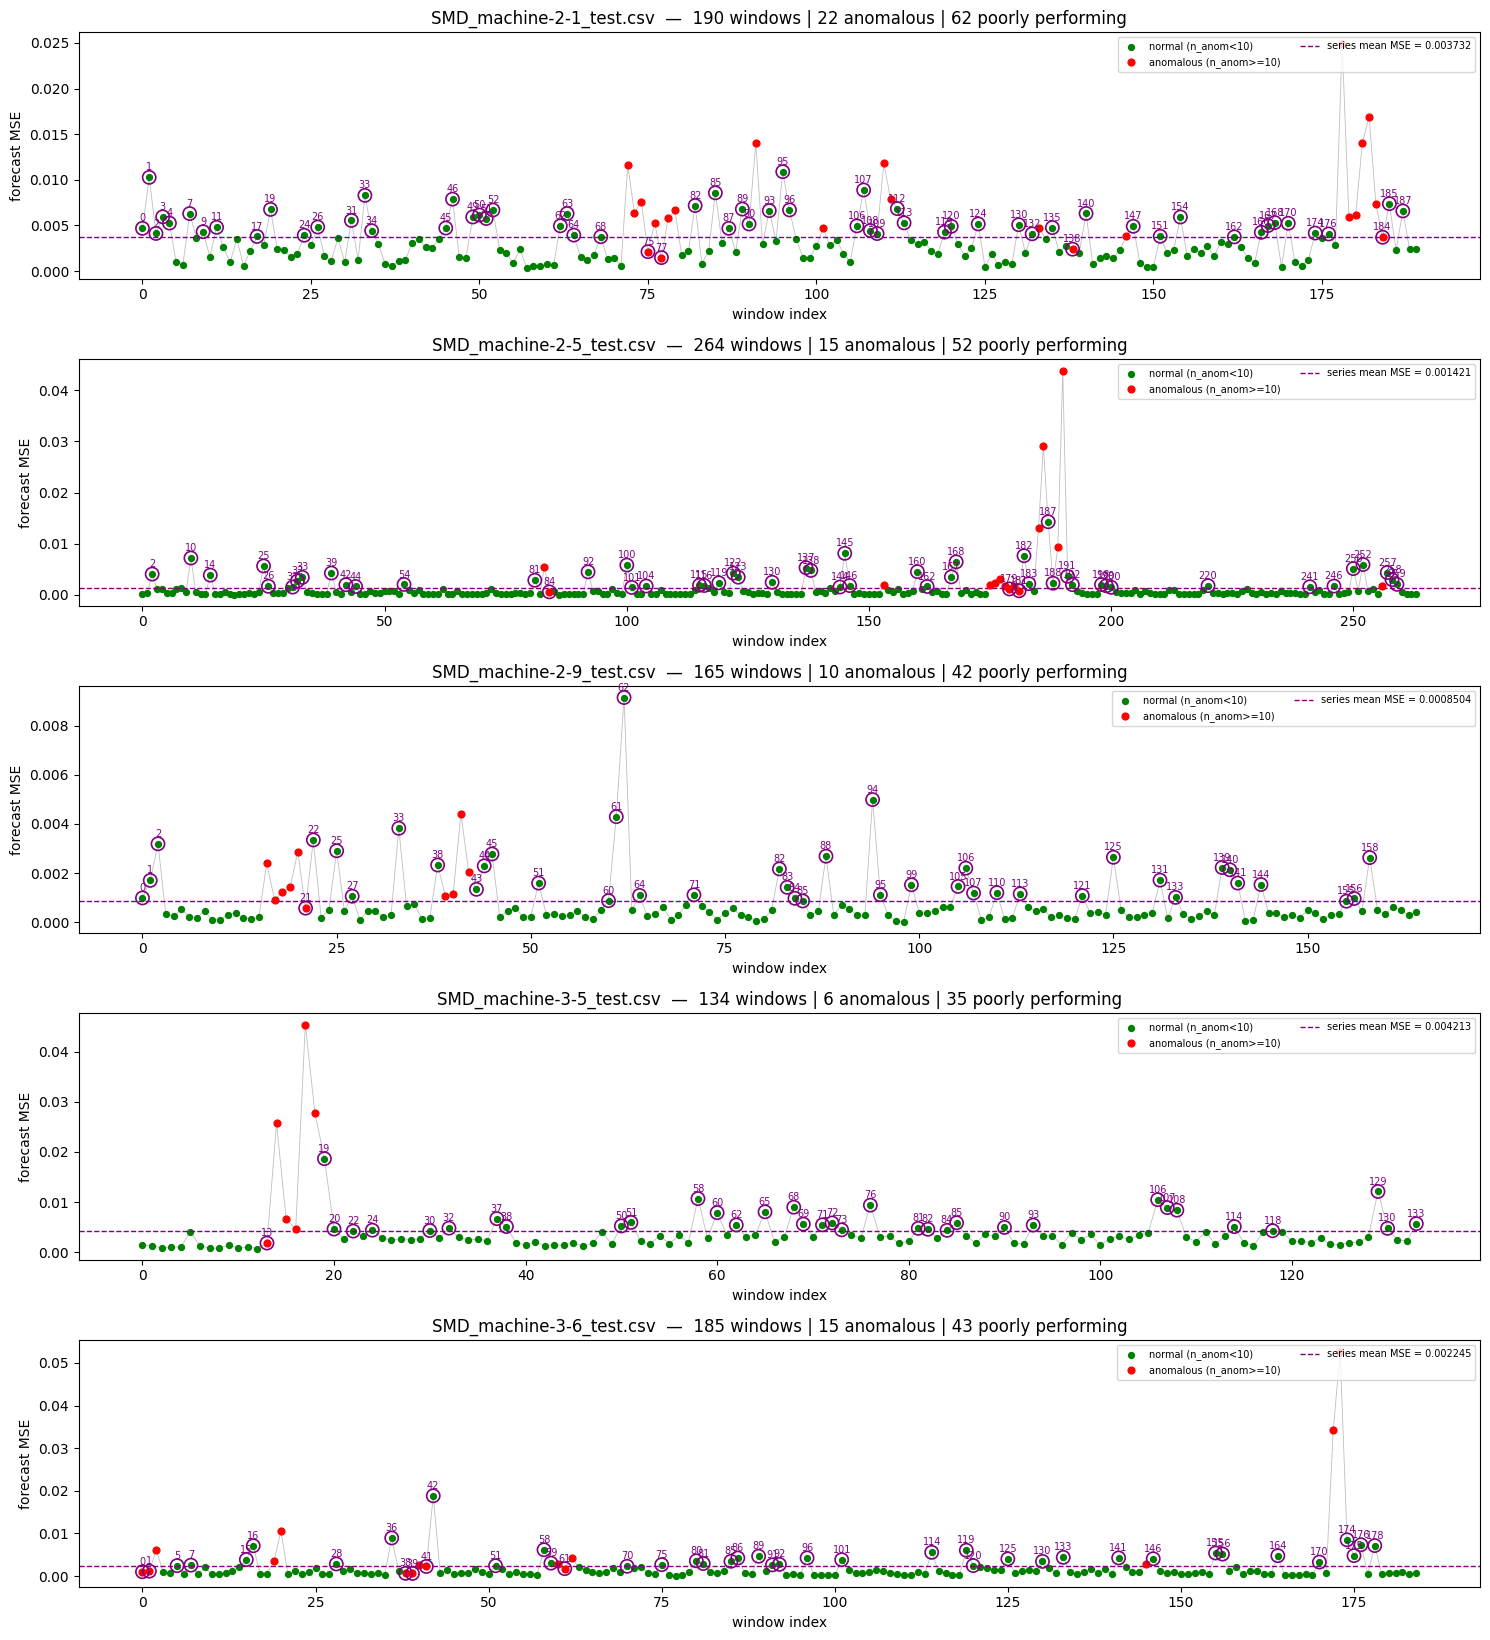

Poorly-performing windows  (normal with MSE > series-mean, OR anomalous with MSE < series-mean):

  SMD_machine-2-1_test.csv: 62 poor (58 normal>mean, 4 anomalous<mean)
      win_idx = [0, 1, 2, 3, 4, 7, 9, 11, 17, 19, 24, 26, 31, 33, 34, 45, 46, 49, 50, 51, 52, 62, 63, 64, 68, 75, 77, 82, 85, 87, 89, 90, 93, 95, 96, 106, 107, 108, 109, 112, 113, 119, 120, 124, 130, 132, 135, 138, 140, 147, 151, 154, 162, 166, 167, 168, 170, 174, 176, 184, 185, 187]
  SMD_machine-2-5_test.csv: 52 poor (49 normal>mean, 3 anomalous<mean)
      win_idx = [2, 10, 14, 25, 26, 31, 32, 33, 39, 42, 44, 54, 81, 84, 92, 100, 101, 104, 115, 116, 119, 122, 123, 130, 137, 138, 144, 145, 146, 160, 162, 167, 168, 179, 181, 182, 183, 187, 188, 191, 192, 198, 199, 200, 220, 241, 246, 250, 252, 257, 258, 259]
  SMD_machine-2-9_test.csv: 42 poor (41 normal>mean, 1 anomalous<mean)
      win_idx = [0, 1, 2, 21, 22, 25, 27, 33, 38, 43, 44, 45, 51, 60, 61, 62, 64, 71, 82, 83, 84, 85, 88, 94, 95, 99, 105, 106, 107, 110, 113, 

In [8]:
import matplotlib.pyplot as plt

# A window is "anomalous" exactly as in training data prep (run_finetune_smd.sh):
#   future_type = 1 (anomaly) iff it contains >= ANOMALY_THRESHOLD anomalous steps.
ANOMALY_THRESHOLD = 10
mse_df["is_anom_window"] = mse_df["n_anom"] >= ANOMALY_THRESHOLD

# "Poorly performing" is judged against the series' MEAN MSE, and the direction
# depends on the window type (a good model forecasts normals well = low MSE, and
# fails on anomalies = high MSE):
#   - NORMAL  window poorly performing iff  mse >  series-mean  (error too high)
#   - ANOMALY window poorly performing iff  mse <  series-mean  (error too low -> hidden)
series_ids = sorted(mse_df["series_id"].unique())
n = len(series_ids)
fig, axes = plt.subplots(n, 1, figsize=(15, 3.3 * n), squeeze=False)
axes = axes[:, 0]

poor = {}   # series_id -> list of poorly-performing window indices

for ax, sid in zip(axes, series_ids):
    sub  = mse_df[mse_df.series_id == sid].sort_values("win_idx")
    x    = sub["win_idx"].to_numpy()
    y    = sub["mse"].to_numpy()
    anom = sub["is_anom_window"].to_numpy()

    mean_mse = y.mean()                                   # mean over the whole series
    bad = ((~anom) & (y > mean_mse)) | (anom & (y < mean_mse))
    poor[sid] = x[bad].tolist()

    ax.plot(x, y, color="0.75", lw=0.6, zorder=1)                         # connecting line
    ax.scatter(x[~anom], y[~anom], c="green", s=18, zorder=2,
               label=f"normal (n_anom<{ANOMALY_THRESHOLD})")
    ax.scatter(x[anom],  y[anom],  c="red",   s=24, zorder=3,
               label=f"anomalous (n_anom>={ANOMALY_THRESHOLD})")
    ax.axhline(mean_mse, color="purple", ls="--", lw=1,
               label=f"series mean MSE = {mean_mse:.4g}")
    # ring + label the poorly-performing windows
    ax.scatter(x[bad], y[bad], s=90, facecolors="none", edgecolors="purple",
               linewidths=1.2, zorder=4)
    for xi, yi in zip(x[bad], y[bad]):
        ax.annotate(str(xi), (xi, yi), fontsize=7, color="purple",
                    xytext=(0, 5), textcoords="offset points", ha="center")
    ax.set(title=f"{sid}  —  {len(sub)} windows | "
                 f"{int(anom.sum())} anomalous | {int(bad.sum())} poorly performing",
           xlabel="window index", ylabel="forecast MSE")
    ax.legend(loc="upper right", fontsize=7, ncol=2)

plt.tight_layout(); plt.show()

# ── Print the poorly-performing window indices per series ────────────────────
print("Poorly-performing windows  "
      "(normal with MSE > series-mean, OR anomalous with MSE < series-mean):\n")
for sid in series_ids:
    sub = mse_df[mse_df.series_id == sid].sort_values("win_idx")
    idxs = poor[sid]
    bad_mask = sub["win_idx"].isin(idxs)
    n_norm_bad = int((bad_mask & ~sub["is_anom_window"]).sum())
    n_anom_bad = int((bad_mask &  sub["is_anom_window"]).sum())
    print(f"  {sid}: {len(idxs)} poor "
          f"({n_norm_bad} normal>mean, {n_anom_bad} anomalous<mean)")
    print(f"      win_idx = {idxs}")


In [9]:
windows[82]

{'target': array([[0.141414, 0.151515, 0.161616, ..., 0.070707, 0.090909, 0.10101 ],
        [0.017694, 0.017735, 0.014451, ..., 0.005337, 0.007882, 0.008827],
        [0.0409  , 0.039045, 0.036786, ..., 0.006615, 0.008632, 0.010165],
        ...,
        [0.194631, 0.190157, 0.163311, ..., 0.080537, 0.089485, 0.118568],
        [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
        [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ]],
       shape=(38, 832), dtype=float32),
 'future_labels': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       dtype=int32),
 'series_id': 'SMD_machine-2-1_test.csv',
 'future_start': 5760,
 'future_end': 5824,
 'series_length': 12706}

## 7. Burst-type analysis — actual, forecasted & MSE per anomaly type

Anomalies are grouped by **event length** (a contiguous run of `label==1`):

| bucket | length | meaning |
|---|---|---|
| `pointwise` | 1 | a single lone anomaly (**none in SMD**) |
| `short` | 2–5 | near-pointwise |
| `medium` | 6–20 | |
| `long` | 21–64 | within a single forecast window |
| `burst` | > 64 | multi-window burst |

For each test file we compute and **store three things** per event / per timestep —
the **actual**, the **forecast (q50)**, and the **MSE** — then plot them:

- **7a** per file: actual vs forecast (worst channel) and per-step MSE, with each
  anomaly event shaded by its burst type.
- **7b** per file: mean MSE for each burst type (vs a normal-region baseline).

Outputs: `burst_analysis.pkl` (full `actual`/`forecast`/`mse_t` arrays + per-event
records), `per_event_mse.csv`, `mse_by_burst_type.csv`.

> Re-run sections 4–5 first: the forecast (`q50`) and actual are now captured on the
> series timeline (`fc_q50`, `actual_full`) during inference, which section 7 needs.

In [13]:
# ── 7. Burst-type analysis: actual, forecasted (q50) and MSE per anomaly type ──
# An anomaly EVENT is a contiguous run of label==1. We bucket events by length and,
# per test file, reconstruct the per-timestep MSE (channel mean of the squared
# error already in `feat_scores`) alongside the stored actual / q50 forecast.
import matplotlib.pyplot as plt

assert SCORE_METHOD == "mse", "burst MSE analysis assumes SCORE_METHOD='mse'"

# Burst types by event length (run length of label==1). pointwise(=1) is empty for SMD.
BURST_BUCKETS = [(1, 1, "pointwise"), (2, 5, "short"), (6, 20, "medium"),
                 (21, 64, "long"), (65, 10**9, "burst")]
BUCKET_COLORS = {"pointwise": "#d62728", "short": "#ff7f0e", "medium": "#9467bd",
                 "long": "#1f77b4", "burst": "#8c564b"}
BUCKET_ORDER = [b[2] for b in BURST_BUCKETS]

def burst_type(L):
    for lo, hi, name in BURST_BUCKETS:
        if lo <= L <= hi:
            return name
    return "burst"

def anomaly_events(lbl):
    """Contiguous label==1 runs -> list of (start, end_exclusive, length)."""
    ev, i, n = [], 0, len(lbl)
    while i < n:
        if lbl[i] == 1:
            j = i
            while j < n and lbl[j] == 1:
                j += 1
            ev.append((i, j, j - i)); i = j
        else:
            i += 1
    return ev

burst = {}        # sid -> {actual, forecast, mse_t, lo, hi, events:[...]}
event_rows = []
for sid, m in meta.items():
    lo, hi = covered[sid]
    if lo is None:
        continue
    mse_t = np.nanmean(feat_scores[sid], axis=0)         # (T,) per-step MSE (channel mean)
    evs = []
    for s, e, L in anomaly_events(m["labels"].astype(int)):
        if e <= lo or s >= hi:                           # event lies in the un-scored
            continue                                     # leading context (first `lo` steps)
        cs, ce = max(s, lo), min(e, hi)
        rec = dict(start=int(s), end=int(e), length=int(L),
                   bucket=burst_type(L), mse=float(np.nanmean(mse_t[cs:ce])))
        evs.append(rec)
        event_rows.append(dict(series_id=sid, **rec))
    burst[sid] = dict(actual=actual_full[sid], forecast=fc_q50[sid],
                      mse_t=mse_t, lo=lo, hi=hi, events=evs)

event_df = pd.DataFrame(event_rows).sort_values(["series_id", "start"]).reset_index(drop=True)

# mean MSE per (test file, burst type) -- the headline table
by_type = (event_df.groupby(["series_id", "bucket"])
           .agg(n_events=("length", "size"), mean_len=("length", "mean"),
                total_anom_steps=("length", "sum"), mean_mse=("mse", "mean"))
           .reset_index())

# ── store: full arrays (actual/forecast/mse_t + events) and tidy CSVs ──────────
BURST_PKL = os.path.join(HERE, "burst_analysis.pkl")
with open(BURST_PKL, "wb") as f:
    pickle.dump({"burst": burst, "buckets": BURST_BUCKETS}, f)
event_df.to_csv(os.path.join(HERE, "per_event_mse.csv"), index=False)
by_type.to_csv(os.path.join(HERE, "mse_by_burst_type.csv"), index=False)

print(f"{len(event_df)} scored anomaly events across {event_df.series_id.nunique()} test files "
      f"-> burst_analysis.pkl, per_event_mse.csv, mse_by_burst_type.csv")
print("(events lying entirely within the leading context_length are skipped — never forecast)\n")
print(by_type.to_string(index=False))

42 scored anomaly events across 5 test files -> burst_analysis.pkl, per_event_mse.csv, mse_by_burst_type.csv
(events lying entirely within the leading context_length are skipped — never forecast)

               series_id bucket  n_events   mean_len  total_anom_steps  mean_mse
SMD_machine-2-1_test.csv  burst         3 305.000000               915  0.009950
SMD_machine-2-1_test.csv   long         2  27.000000                54  0.006875
SMD_machine-2-1_test.csv medium         4  13.250000                53  0.013657
SMD_machine-2-5_test.csv  burst         3 183.666667               551  0.023995
SMD_machine-2-5_test.csv   long         3  24.000000                72  0.007441
SMD_machine-2-5_test.csv medium         4   8.500000                34  0.007446
SMD_machine-2-5_test.csv  short         6   3.000000                18  0.014913
SMD_machine-2-9_test.csv  burst         2 287.000000               574  0.002032
SMD_machine-2-9_test.csv  short         3   2.333333                 7  0.

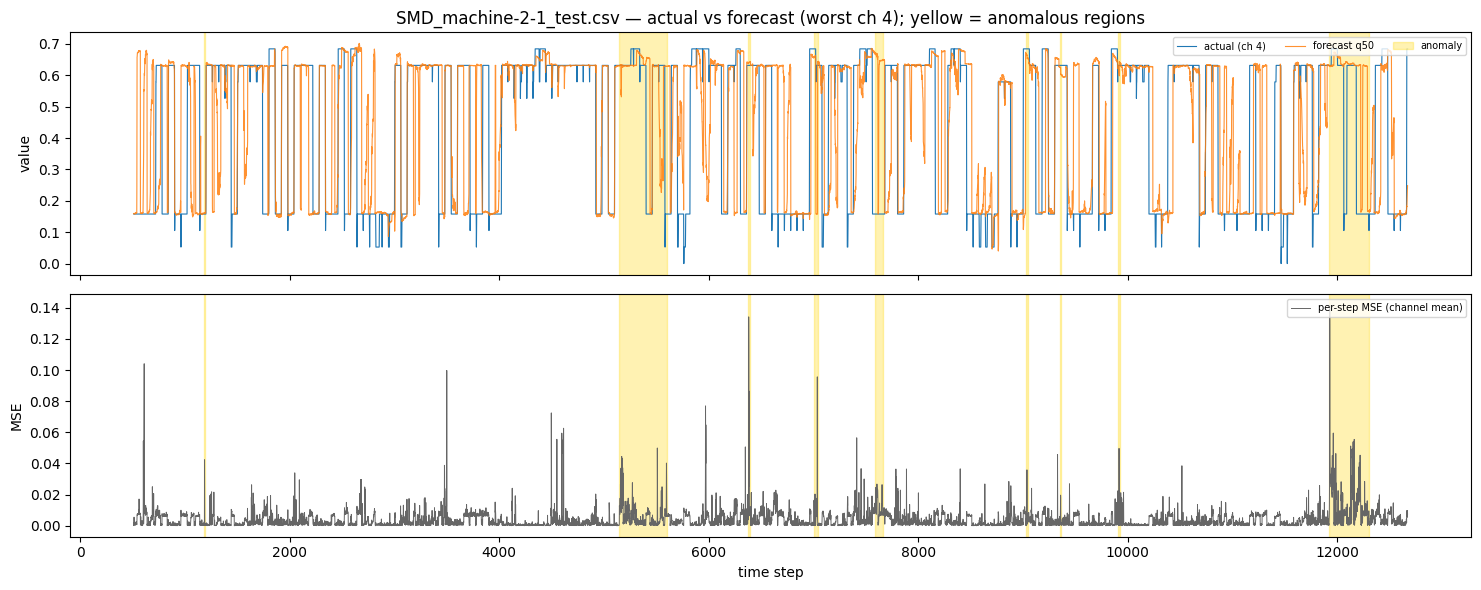

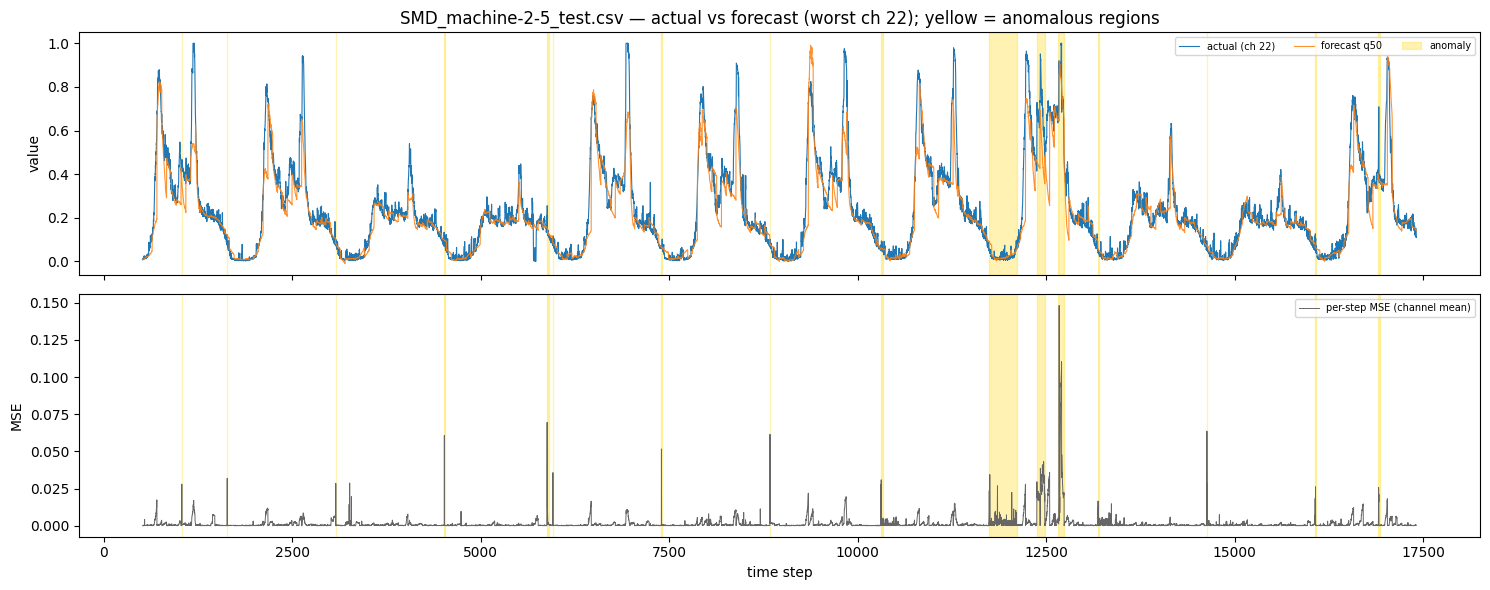

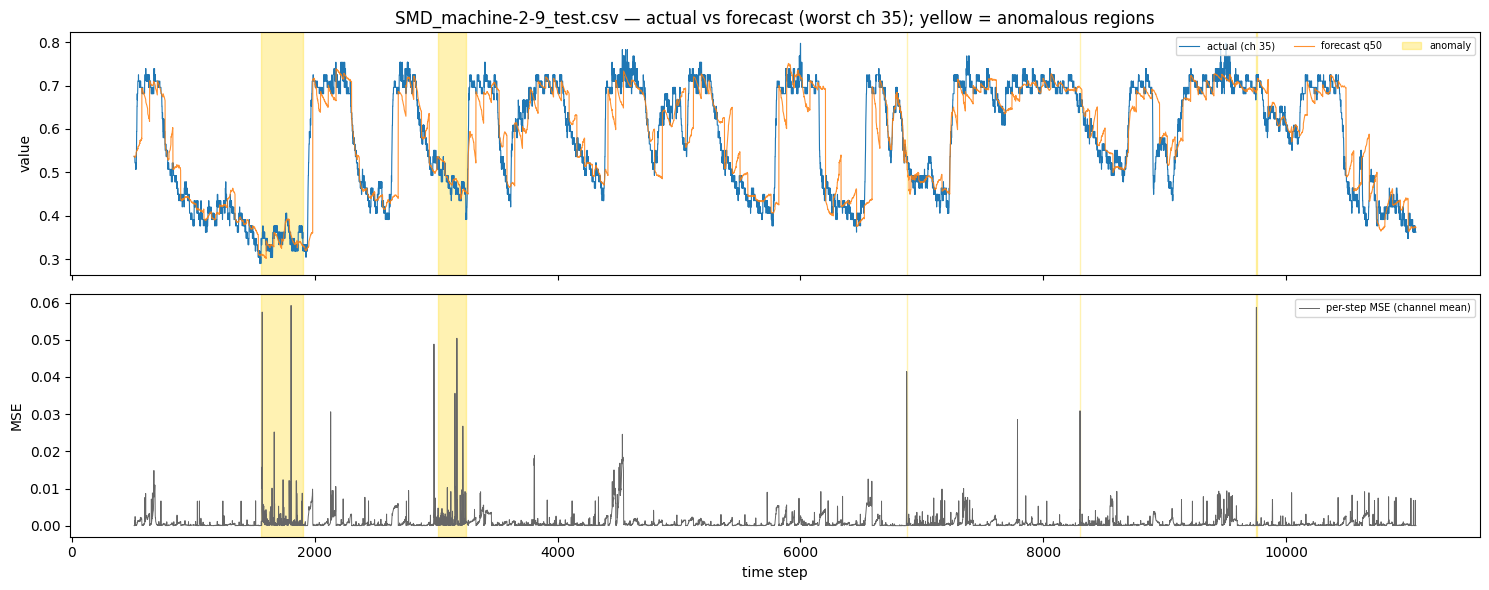

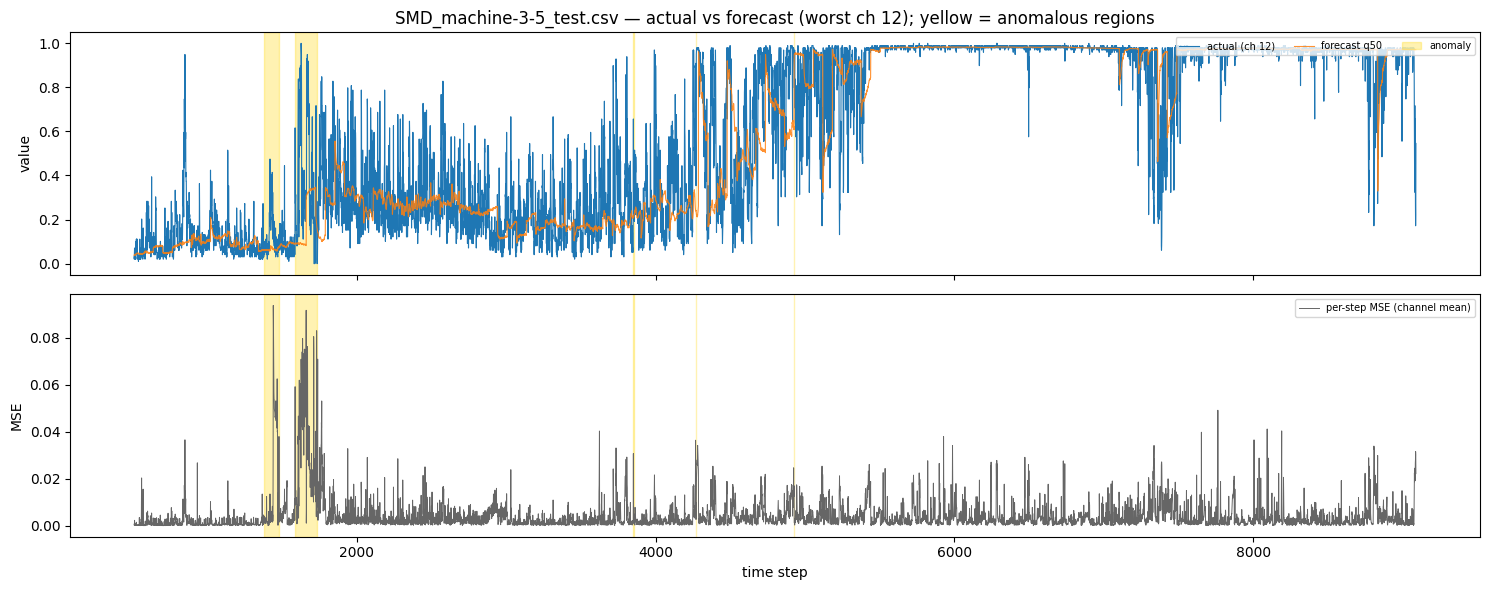

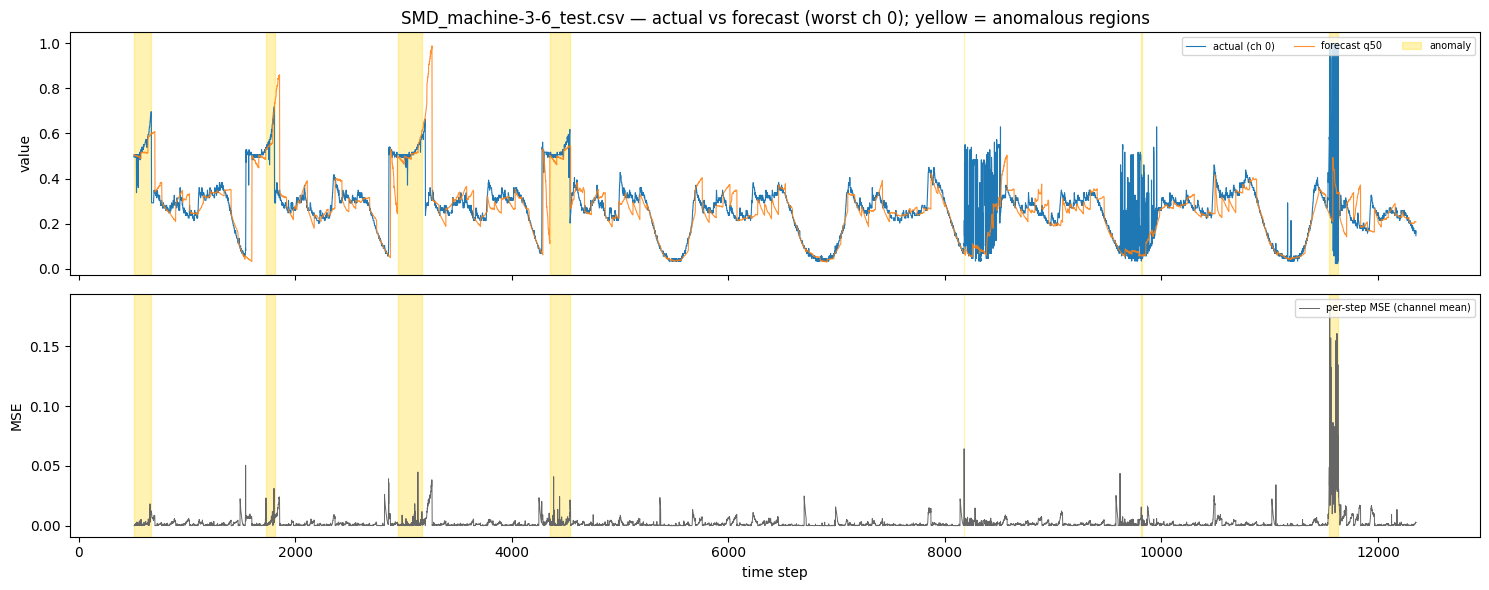

In [14]:
# ── 7a. Per test file: actual vs forecast (worst channel) + per-step MSE ───────
# actual = blue, forecast q50 = orange; anomalous regions shaded yellowish.
# The top panel uses the channel with the highest mean error (most informative);
# every channel is available in burst_analysis.pkl if you want a different one.
for sid in sorted(burst):
    d = burst[sid]; lo, hi = d["lo"], d["hi"]; t = np.arange(lo, hi)
    ch = int(np.nanmean(feat_scores[sid][:, lo:hi], axis=1).argmax())
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
    ax1.plot(t, d["actual"][ch, lo:hi],   color="tab:blue",   lw=0.8, label=f"actual (ch {ch})")
    ax1.plot(t, d["forecast"][ch, lo:hi], color="tab:orange", lw=0.8, alpha=0.85, label="forecast q50")
    ax2.plot(t, d["mse_t"][lo:hi],        color="0.4",        lw=0.7, label="per-step MSE (channel mean)")
    shown = False
    for ev in d["events"]:
        lab = "anomaly" if not shown else None
        ax1.axvspan(max(ev["start"], lo), min(ev["end"], hi), color="gold", alpha=0.30, label=lab)
        ax2.axvspan(max(ev["start"], lo), min(ev["end"], hi), color="gold", alpha=0.30)
        shown = True
    ax1.set(title=f"{sid} — actual vs forecast (worst ch {ch}); yellow = anomalous regions",
            ylabel="value")
    ax2.set(xlabel="time step", ylabel="MSE")
    ax1.legend(loc="upper right", fontsize=7, ncol=3)
    ax2.legend(loc="upper right", fontsize=7)
    plt.tight_layout(); plt.show()

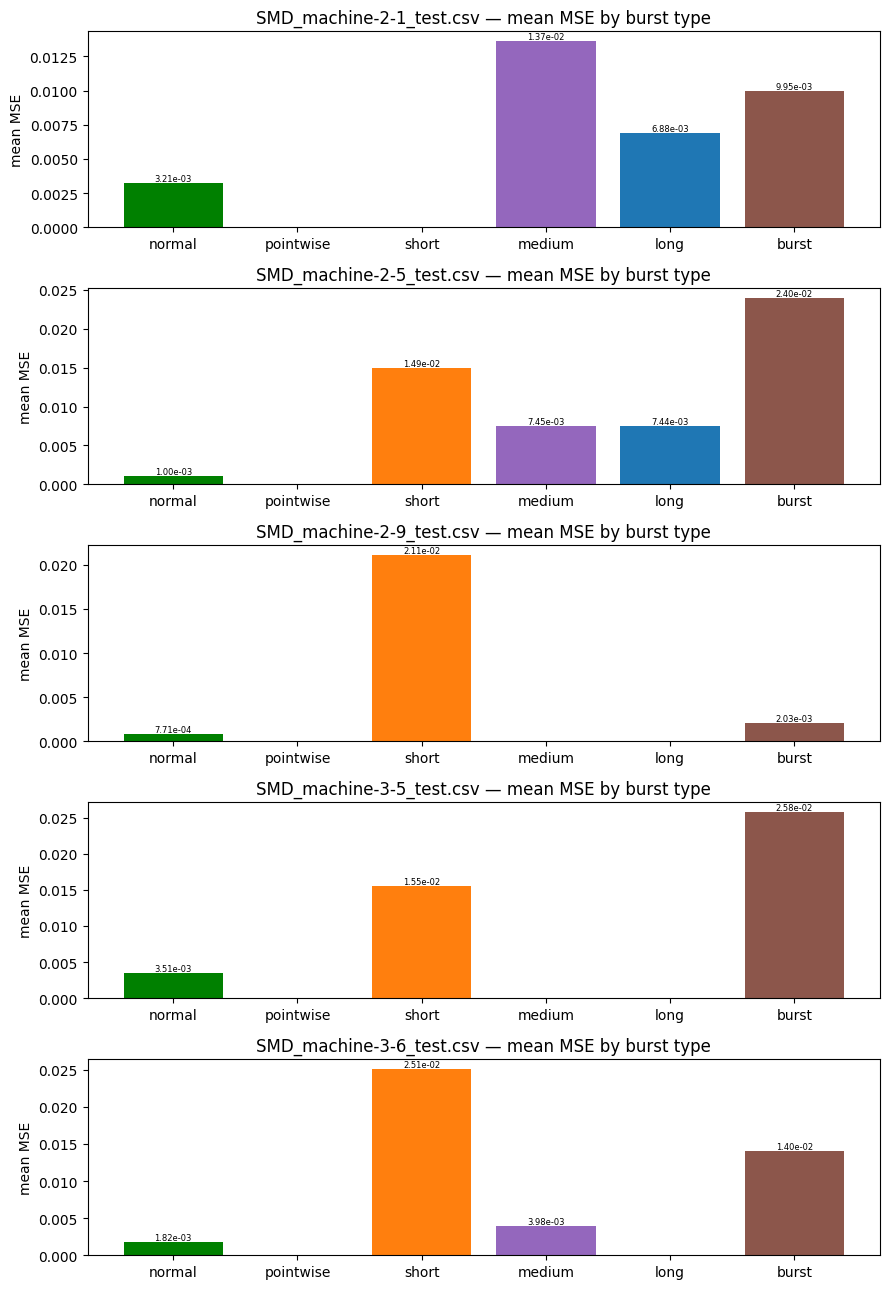

In [15]:
# ── 7b. Mean MSE by burst type, per test file (with a normal-region baseline) ──
# The headline "MSE for different burst types": one bar group per test file. The
# green 'normal' bar is the mean per-step MSE over non-anomalous covered steps.
files = sorted(burst)
fig, axes = plt.subplots(len(files), 1, figsize=(9, 2.6 * len(files)), squeeze=False)
axes = axes[:, 0]
for ax, sid in zip(axes, files):
    d = burst[sid]; lo, hi = d["lo"], d["hi"]
    lbl = meta[sid]["labels"][lo:hi].astype(bool)
    normal_mse = float(np.nanmean(d["mse_t"][lo:hi][~lbl])) if (~lbl).any() else np.nan
    sub = by_type[by_type.series_id == sid].set_index("bucket")["mean_mse"].reindex(BUCKET_ORDER)
    cats   = ["normal"] + BUCKET_ORDER
    vals   = [normal_mse] + sub.tolist()
    colors = ["green"] + [BUCKET_COLORS[b] for b in BUCKET_ORDER]
    bars = ax.bar(range(len(cats)), vals, color=colors)
    for r, v in zip(bars, vals):
        if v == v:                                  # skip NaN (empty bucket)
            ax.text(r.get_x() + r.get_width() / 2, v, f"{v:.2e}",
                    ha="center", va="bottom", fontsize=6)
    ax.set_xticks(range(len(cats))); ax.set_xticklabels(cats)
    ax.set(title=f"{sid} — mean MSE by burst type", ylabel="mean MSE")
plt.tight_layout(); plt.show()